# Chaotic attractors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import odeint

In [2]:
def lorenz(state, t, sigma=10, rho=28, beta=8 / 3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

In [3]:
def plot_lorenz():
    # Initial conditions and time
    state0 = [1.0, 1.0, 1.0]
    t = np.linspace(0, 50, 10000)

    # Solve ODE
    states = odeint(lorenz, state0, t)

    # Plot
    fig = plt.figure(figsize=(12, 5))

    # 3D plot
    ax1 = fig.add_subplot(121, projection="3d")
    ax1.plot(states[:, 0], states[:, 1], states[:, 2], "b-", alpha=0.6, linewidth=0.5)
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.set_title("Lorenz Attractor (3D)")

    # 2D projection
    ax2 = fig.add_subplot(122)
    ax2.plot(states[:, 0], states[:, 2], "r-", alpha=0.6, linewidth=0.5)
    ax2.set_xlabel("X")
    ax2.set_ylabel("Z")
    ax2.set_title("Lorenz Attractor (X-Z Projection)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Generated {len(states)} points")

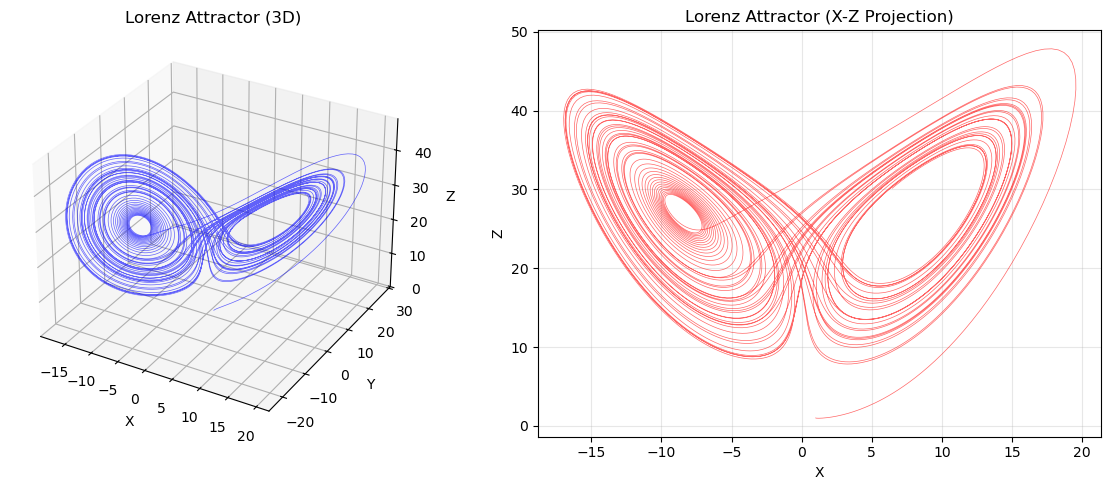

Generated 10000 points


In [6]:
plot_lorenz()

In [4]:
def dejong_attractor(n_points=100000, a=1.4, b=-2.3, c=2.4, d=-2.1):
    x = np.zeros(n_points)
    y = np.zeros(n_points)

    x[0], y[0] = 0, 0

    for i in range(n_points - 1):
        x[i + 1] = np.sin(a * y[i]) - np.cos(b * x[i])
        y[i + 1] = np.sin(c * x[i]) - np.cos(d * y[i])

    return x, y

In [5]:
def plot_dejong():
    # Generate different De Jong attractors
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    params = [
        (1.4, -2.3, 2.4, -2.1),
        (-2.0, -2.0, -1.2, 2.0),
        (2.01, -2.53, 1.61, -0.33),
        (-2.7, -0.09, -0.86, -2.2),
    ]

    for ax, (a, b, c, d) in zip(axes.flat, params):
        x, y = dejong_attractor(50000, a, b, c, d)
        ax.scatter(x, y, s=0.1, c="cyan", alpha=0.5)
        ax.set_title(f"a={a}, b={b}, c={c}, d={d}")
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_facecolor("black")
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

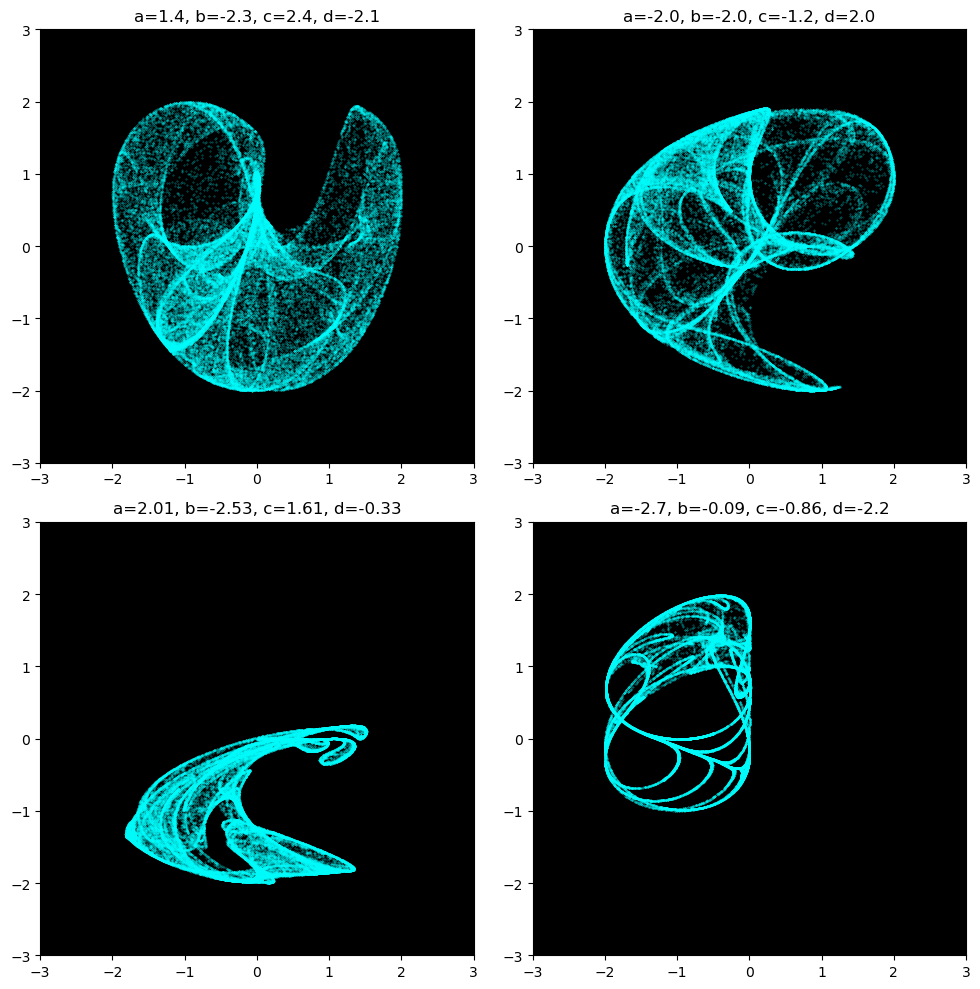

In [7]:
plot_dejong()